# Internet Advertisements

# Cell 0 — Import libraries

**Mục đích**
- Nạp các thư viện cần cho toàn bộ pipeline phân tích.
- `pandas`, `numpy`: xử lý dữ liệu.
- `matplotlib`, `seaborn`: trực quan hóa.
- `scipy`, `statsmodels`: kiểm định thống kê.
- `scikit-learn`: tiền xử lý, mô hình hóa và đánh giá.

**Ghi chú**
- Nếu máy chưa có `statsmodels` thì cell proportion test sẽ tự bỏ qua.

In [1]:
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import probplot

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay,
)

try:
    from statsmodels.stats.proportion import proportions_ztest
    HAS_STATSMODELS = True
except Exception:
    HAS_STATSMODELS = False

sns.set_theme(style="whitegrid")

# Cell 1 — LOAD DATA

**Mục đích**
- Đọc file dữ liệu gốc vào `DataFrame`.
- Sửa `DATA_PATH` cho đúng vị trí file trên máy/Kaggle.

**Đầu ra**
- `ad_data`: bảng dữ liệu thô.
- In ra kích thước dữ liệu ban đầu để kiểm tra tải file thành công.

In [2]:
# EDIT THIS PATH
DATA_PATH = "/kaggle/input/datasets/organizations/uciml/internet-advertisements-data-set/add.csv"   # or "/kaggle/input/.../ad.data"

ad_data = pd.read_csv(
    DATA_PATH,
    index_col=0,       # Set 1st column as Index
    header=0,          # Use 1st row as Header
    na_values="?",
    low_memory=False
)

#ad_data.head()
#ad_data.tail()

print("Raw shape:", ad_data.shape)

Raw shape: (3279, 1559)


# Cell 2 — SET COLUMN NAMES

**Mục đích**
- Đặt tên cột rõ ràng cho dữ liệu thay vì để chỉ số số nguyên.
- Nhóm cột được đặt theo logic của bộ Internet Advertisements:
  - `height`, `width`, `ratio`, `local`
  - các nhóm từ khóa URL / original URL / anchor URL / alt / caption
  - `Class`

**Đầu ra**
- Dữ liệu có tên cột dễ đọc và thuận tiện cho báo cáo.

In [3]:
colnames = (
    ["height", "width", "ratio", "local"]
    + [f"url_{i}" for i in range(1, 458)]
    + [f"origurl_{i}" for i in range(1, 496)]
    + [f"ancurl_{i}" for i in range(1, 473)]
    + [f"alt_{i}" for i in range(1, 112)]
    + [f"caption_{i}" for i in range(1, 20)]
    + ["Class"]
)
ad_data.columns = colnames

# show selected columns
df_show = ad_data.iloc[:, list(range(5)) + list(range(ad_data.shape[1] - 4, ad_data.shape[1]))].copy()
df_show.columns = list(ad_data.columns[:4]) + ["..."] + list(ad_data.columns[-4:])
print("\nPreview subset:")
print(df_show.head())


Preview subset:
  height width   ratio  local  ...  caption_17  caption_18  caption_19 Class
0    125   125       1    1.0    0           0           0           0   ad.
1     57   468  8.2105    1.0    0           0           0           0   ad.
2     33   230  6.9696    1.0    0           0           0           0   ad.
3     60   468     7.8    1.0    0           0           0           0   ad.
4     60   468     7.8    1.0    0           0           0           0   ad.


# Cell 3 — BASIC CLEANING

**Mục đích**
- Xóa khoảng trắng thừa.
- Chuyển `"?"` thành `NaN`.
- Ép toàn bộ feature về dạng số.
- Chuẩn hóa nhãn `Class` thành:
  - `1` = ad
  - `0` = nonad

**Ý nghĩa**
- Đây là bước quan trọng trước EDA và modeling.

In [4]:
# trim whitespace for object columns
obj_cols = ad_data.select_dtypes(include=["object"]).columns
ad_data[obj_cols] = ad_data[obj_cols].apply(lambda s: s.str.strip())

# replace "?" again after trim
ad_data = ad_data.replace(r'^\s*\?\s*$', np.nan, regex=True)

# convert feature columns to numeric
feature_cols = ad_data.columns[:-1]
ad_data[feature_cols] = ad_data[feature_cols].apply(pd.to_numeric, errors="coerce")

# local to numeric
ad_data["local"] = pd.to_numeric(ad_data["local"], errors="coerce")

# Class: remove "." and convert ad->1, nonad->0
ad_data["Class"] = (
    ad_data["Class"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .str.strip()
)
ad_data["Class"] = np.where(ad_data["Class"] == "ad", 1, 0).astype(int)

# Cell 4 — MISSING VALUE CHECK

**Mục đích**
- Đếm số lượng `NA` theo từng cột.
- Tính tỷ lệ thiếu để biết cột nào cần chú ý.

**Đầu ra**
- Bảng `na_result` để đưa vào báo cáo.

In [5]:
na_count = ad_data.isna().sum()
na_cols = na_count[na_count > 0]
na_ratio = (na_cols / len(ad_data) * 100).round(2)

na_result = pd.DataFrame({
    "Column": na_cols.index,
    "NA_Count": na_cols.values,
    "NA_Ratio_Percent": na_ratio.values
})
print("\nColumns with NA:")
print(na_result.to_string(index=False))


Columns with NA:
Column  NA_Count  NA_Ratio_Percent
height       903             27.54
 width       901             27.48
 ratio       910             27.75
 local        15              0.46


# Cell 5 — REMOVE `ratio` COLUMN

**Mục đích**
- Loại bỏ `ratio` vì biến này có thể suy ra từ `height` và `width`.
- Tránh dư thừa thông tin và giúp mô hình gọn hơn.

In [6]:
ad_data = ad_data.drop(columns=["ratio"])

# Cell 6 — EDA

**Mục đích**
- Vẽ histogram và boxplot cho `height`, `width`.
- Vẽ phân phối của `local`.

**Ý nghĩa**
- Nhìn nhanh phân phối, độ lệch và khả năng có outlier.
- Trực quan hóa.

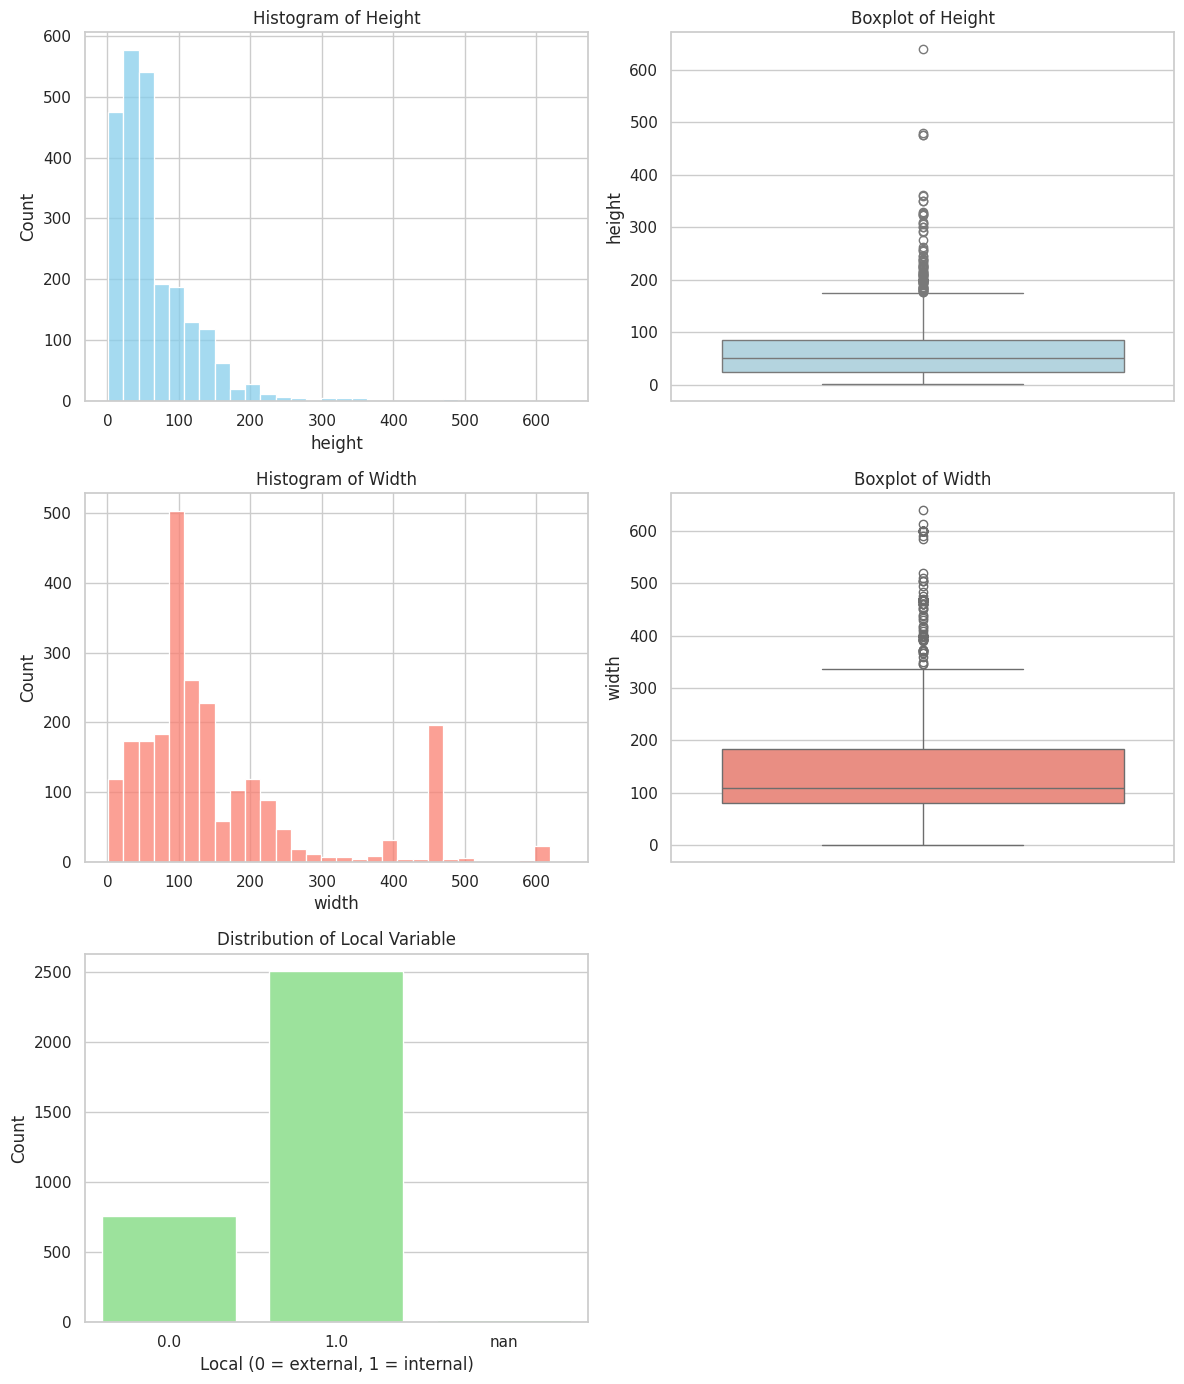

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(12, 14))

sns.histplot(ad_data["height"], bins=30, kde=False, ax=axes[0, 0], color="skyblue")
axes[0, 0].set_title("Histogram of Height")

sns.boxplot(y=ad_data["height"], ax=axes[0, 1], color="lightblue")
axes[0, 1].set_title("Boxplot of Height")

sns.histplot(ad_data["width"], bins=30, kde=False, ax=axes[1, 0], color="salmon")
axes[1, 0].set_title("Histogram of Width")

sns.boxplot(y=ad_data["width"], ax=axes[1, 1], color="salmon")
axes[1, 1].set_title("Boxplot of Width")

local_counts = ad_data["local"].value_counts(dropna=False).sort_index()
sns.barplot(x=local_counts.index.astype(str), y=local_counts.values, ax=axes[2, 0], color="lightgreen")
axes[2, 0].set_title("Distribution of Local Variable")
axes[2, 0].set_xlabel("Local (0 = external, 1 = internal)")
axes[2, 0].set_ylabel("Count")

axes[2, 1].axis("off")
plt.tight_layout()
plt.show()

# Cell 7 — IMPUTE MISSING VALUES

**Mục đích**
- `height`, `width`: điền bằng median.
- `local`: điền bằng 1.

**Lưu ý**
- Đây là bước làm sạch trước khi thống kê và huấn luyện mô hình.

In [8]:
ad_data["height"] = ad_data["height"].fillna(ad_data["height"].median())
ad_data["width"] = ad_data["width"].fillna(ad_data["width"].median())
ad_data["local"] = ad_data["local"].fillna(1)

# Cell 8 - OUTLIER CHECK

**Mục đích**
- Dùng quy tắc IQR để đếm số outlier ở `height` và `width`.

**Đầu ra**
- Bảng tóm tắt số lượng và tỷ lệ outlier theo từng biến.

In [9]:
def calc_outlier(x: pd.Series) -> pd.Series:
    x = x.dropna()
    q1 = x.quantile(0.25)
    q3 = x.quantile(0.75)
    iqr_val = q3 - q1
    outliers = x[(x < q1 - 1.5 * iqr_val) | (x > q3 + 1.5 * iqr_val)]
    return pd.Series({
        "Count": len(outliers),
        "Percent": round(len(outliers) / len(x) * 100, 2)
    })

outlier_result = pd.DataFrame({
    "height": calc_outlier(ad_data["height"]),
    "width": calc_outlier(ad_data["width"])
}).T
print("\nOutlier summary:")
print(outlier_result)


Outlier summary:
        Count  Percent
height  422.0    12.87
width   429.0    13.08


# Cell 9 — DUPLICATES

**Mục đích**
- Đếm số dòng duplicated.
- Xem nhanh vài dòng trùng đầu tiên.
- Loại các dòng trùng trước khi phân tích/mô hình hóa.

In [10]:
print("\nNumber of duplicated rows:", ad_data.duplicated().sum())
print("\nFirst duplicated rows preview:")
print(ad_data.loc[ad_data.duplicated()].iloc[:5, :10])

ad_data = ad_data.loc[~ad_data.duplicated()].copy()
print("\nShape after removing duplicates:", ad_data.shape)


Number of duplicated rows: 857

First duplicated rows preview:
    height  width  local  url_1  url_2  url_3  url_4  url_5  url_6  url_7
14    33.0  230.0    1.0      0      0      0      0      0      0      0
23    90.0   60.0    1.0      0      0      0      0      0      0      0
41    50.0  107.0    0.0      0      0      0      0      0      0      0
42    50.0  107.0    0.0      0      0      0      0      0      0      0
44   125.0  125.0    1.0      0      0      0      0      0      0      0

Shape after removing duplicates: (2422, 1558)


# Cell 10 — descriptive statistics

**Mục đích**
- In cấu trúc dữ liệu.
- Tóm tắt `height`, `width`.
- Tỷ lệ lớp `Class`.
- Tỷ lệ biến `local`.
- Thống kê trung bình các feature nhị phân.

**Ý nghĩa**
- Đây là phần descriptive statistics.

In [11]:
print("\nStructure:")
print(ad_data.info())

print("\nSummary for height/width:")
print(ad_data[["height", "width"]].describe())

print("\nClass counts:")
print(ad_data["Class"].value_counts())
print("\nClass proportions (%):")
print(ad_data["Class"].value_counts(normalize=True) * 100)

print("\nLocal counts:")
print(ad_data["local"].value_counts(dropna=False))
print("\nLocal proportions (%):")
print(ad_data["local"].value_counts(normalize=True, dropna=False) * 100)

# binary mean for predictors from local onward (excluding Class)
binary_subset = ad_data.iloc[:, 3:-1]
binary_mean = binary_subset.mean(numeric_only=True)
print("\nSummary of binary feature means:")
print(binary_mean.describe())

for c in ["url_1", "url_2", "url_3", "url_4"]:
    if c in binary_mean.index:
        print(c, "=", binary_mean[c])


Structure:
<class 'pandas.core.frame.DataFrame'>
Index: 2422 entries, 0 to 3278
Columns: 1558 entries, height to Class
dtypes: float64(3), int64(1555)
memory usage: 28.8 MB
None

Summary for height/width:
            height        width
count  2422.000000  2422.000000
mean     64.336086   150.691577
std      50.874559   115.269074
min       1.000000     1.000000
25%      33.000000    90.000000
50%      51.000000   110.000000
75%      76.000000   164.000000
max     640.000000   640.000000

Class counts:
Class
0    2036
1     386
Name: count, dtype: int64

Class proportions (%):
Class
0    84.062758
1    15.937242
Name: proportion, dtype: float64

Local counts:
local
1.0    1764
0.0     658
Name: count, dtype: int64

Local proportions (%):
local
1.0    72.83237
0.0    27.16763
Name: proportion, dtype: float64

Summary of binary feature means:
count    1554.000000
mean        0.007834
std         0.016268
min         0.000413
25%         0.003303
50%         0.004955
75%         0.007432

# Cell 11 — CLASS DISTRIBUTION PLOTS

**Mục đích**
- Vẽ phân phối lớp.
- So sánh `height` và `width` theo `Class`.
- So sánh `local` theo `Class`.

**Ý nghĩa**
- Giúp thấy sự khác biệt giữa ad và nonad bằng hình ảnh.

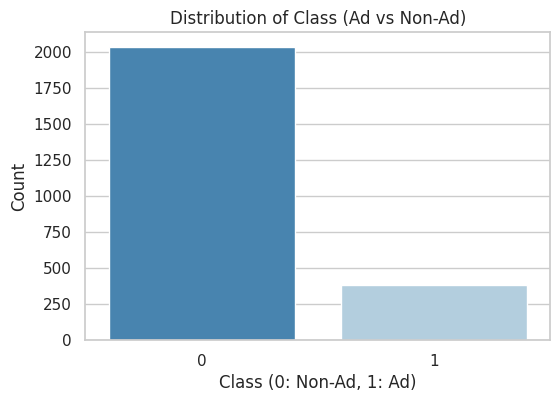

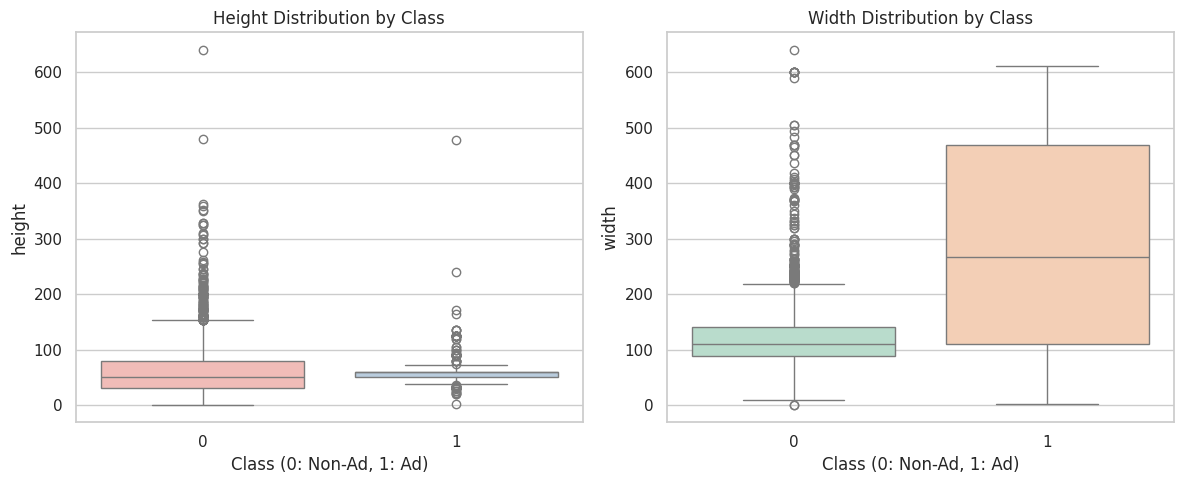

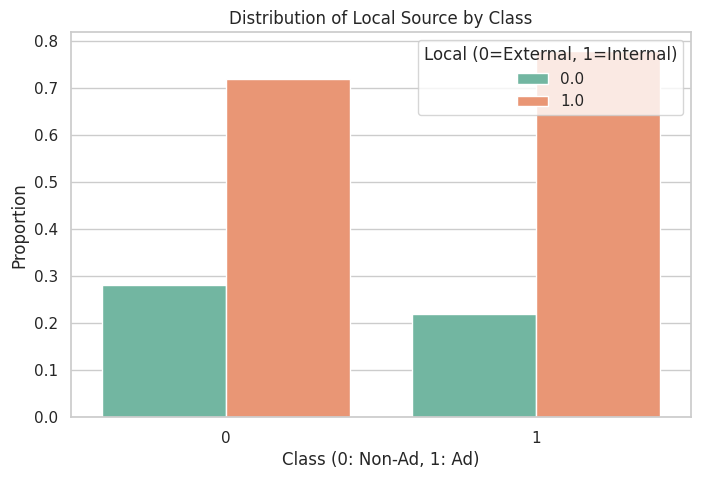

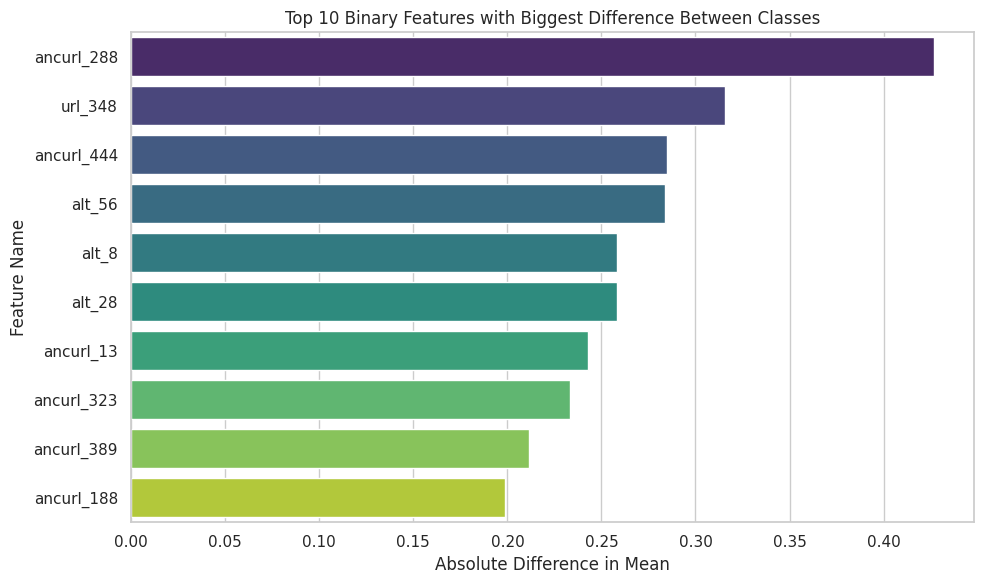

In [12]:
# Distribution of Class
plt.figure(figsize=(6, 4))
sns.countplot(x="Class", data=ad_data, hue="Class", palette="Blues_r", legend=False)
plt.title("Distribution of Class (Ad vs Non-Ad)")
plt.xlabel("Class (0: Non-Ad, 1: Ad)")
plt.ylabel("Count")
plt.show()

# Boxplot by class
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x="Class", y="height", data=ad_data, hue="Class", ax=axes[0], palette="Pastel1", legend=False)
axes[0].set_title("Height Distribution by Class")
axes[0].set_xlabel("Class (0: Non-Ad, 1: Ad)")

sns.boxplot(x="Class", y="width", data=ad_data, hue="Class", ax=axes[1], palette="Pastel2", legend=False)
axes[1].set_title("Width Distribution by Class")
axes[1].set_xlabel("Class (0: Non-Ad, 1: Ad)")

plt.tight_layout()
plt.show()

# Distribution of Local Source by Class
plt.figure(figsize=(8, 5))

local_prop = (
    ad_data.groupby("Class")["local"]
    .value_counts(normalize=True)
    .rename("Proportion")
    .reset_index()
)

sns.barplot(data=local_prop, x="Class", y="Proportion", hue="local", palette="Set2")
plt.title("Distribution of Local Source by Class")
plt.xlabel("Class (0: Non-Ad, 1: Ad)")
plt.ylabel("Proportion")
plt.legend(title="Local (0=External, 1=Internal)")
plt.show()

# Top 10 Binary features
binary_features = ad_data.columns[3:-1] 
mean_by_class = ad_data.groupby("Class")[binary_features].mean()

diff = abs(mean_by_class.loc[1] - mean_by_class.loc[0])
top_10_features = diff.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))

sns.barplot(x=top_10_features.values, y=top_10_features.index, hue=top_10_features.index, palette="viridis", legend=False)
plt.title("Top 10 Binary Features with Biggest Difference Between Classes")
plt.xlabel("Absolute Difference in Mean")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.show()

# Cell 12 — CORRELATION HEATMAP

**Mục đích**
- Xem tương quan giữa các biến chọn lọc quan trọng cùng với `height`, `width`, `local`.

**Ý nghĩa**
- Giải thích dữ liệu và kiểm tra quan hệ giữa biến.

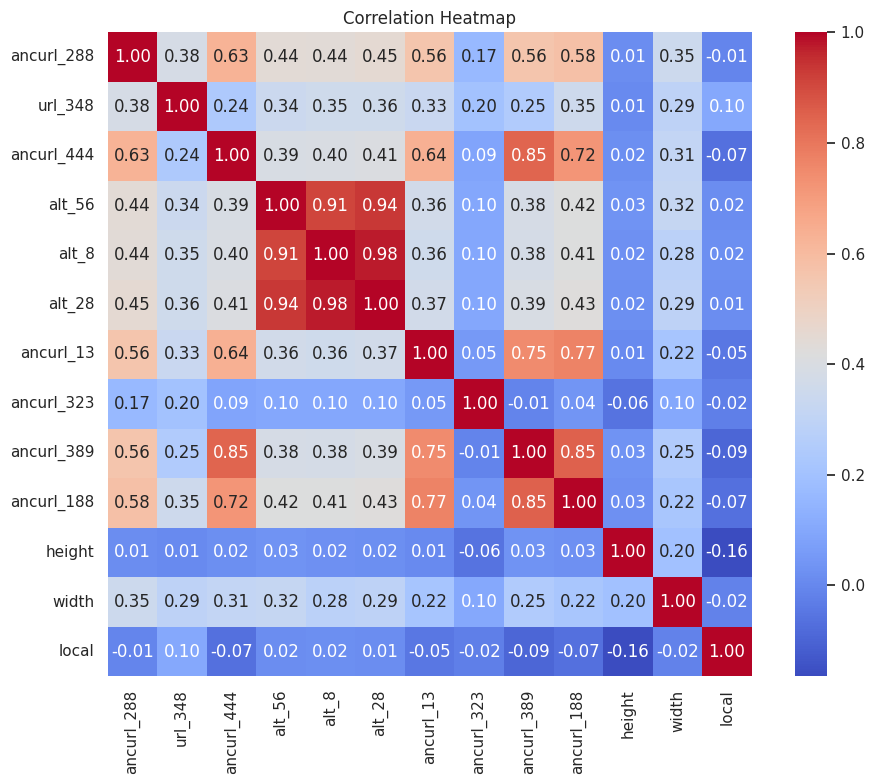

In [13]:
selected_vars = top_10_features.index.tolist() + ["height", "width", "local"]

data_subset = ad_data[selected_vars].copy()
cor_matrix = data_subset.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(cor_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Cell 13 — NORMALITY + QQ PLOT FOR width BY CLASS

**Mục đích**
- Chạy Shapiro-Wilk trên mẫu con.
- Vẽ QQ plot cho `width` theo từng lớp.

**Ý nghĩa**
- Hỗ trợ quyết định dùng kiểm định tham số hay phi tham số.


Shapiro p-values:
   Class       p_value
0      0  5.680871e-27
1      1  2.072697e-22


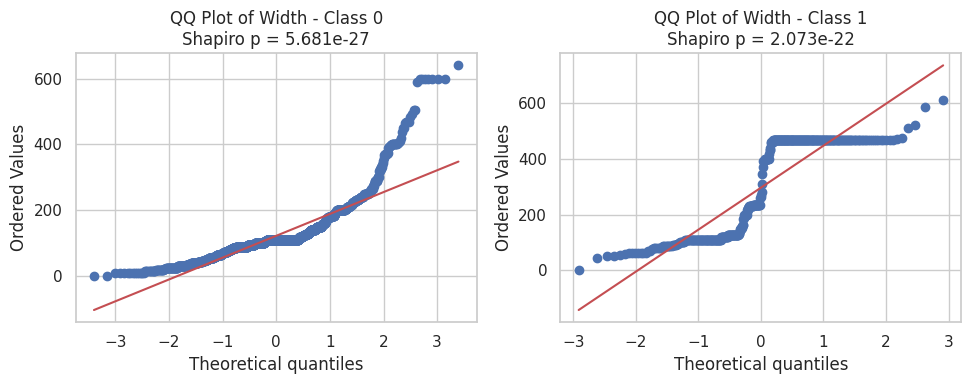

In [14]:
shapiro_results = []
for cls in sorted(ad_data["Class"].unique()):
    sample_x = ad_data.loc[ad_data["Class"] == cls, "width"].dropna()
    sample_x = sample_x.sample(min(500, len(sample_x)), random_state=99)
    p_value = stats.shapiro(sample_x).pvalue
    shapiro_results.append({"Class": cls, "p_value": p_value})
shapiro_df = pd.DataFrame(shapiro_results)
print("\nShapiro p-values:")
print(shapiro_df)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, cls in zip(axes, sorted(ad_data["Class"].unique())):
    vals = ad_data.loc[ad_data["Class"] == cls, "width"].dropna()
    probplot(vals, dist="norm", plot=ax)
    p_val = shapiro_df.loc[shapiro_df["Class"] == cls, "p_value"].iloc[0]
    ax.set_title(f"QQ Plot of Width - Class {cls}\nShapiro p = {p_val:.4g}")
plt.tight_layout()
plt.show()

# Cell 14 — HYPOTHESIS TESTS

**Mục đích**
- Welch t-test cho `width` giữa hai lớp.
- Mann–Whitney U như bản tương đương `wilcox.test` trong R.
- Two-proportion z-test cho biến `local`.

# Welch t-test

Cell này tương ứng với phần `Welch t-test` trong script gốc.

In [15]:
# Welch t-test
width_1 = ad_data.loc[ad_data["Class"] == 1, "width"].dropna()
width_0 = ad_data.loc[ad_data["Class"] == 0, "width"].dropna()
t_test_result = stats.ttest_ind(width_1, width_0, equal_var=False)
print("\nWelch t-test (width ~ Class):")
print(t_test_result)

# Mann-Whitney U 
wilcox_result = stats.mannwhitneyu(width_1, width_0, alternative="two-sided")
print("\nMann-Whitney U test:")
print(wilcox_result)

# Proportion test for local = 1
tab = pd.crosstab(ad_data["Class"], ad_data["local"])
print("\nContingency table Class x local:")
print(tab)

if HAS_STATSMODELS:
    success = np.array([tab.loc[1, 1.0], tab.loc[0, 1.0]], dtype=float)
    n = np.array([tab.loc[1].sum(), tab.loc[0].sum()], dtype=float)
    stat, pval = proportions_ztest(success, n, alternative="larger")
    print("\nTwo-proportion z-test (ad > nonad for local=1):")
    print({"z_stat": stat, "p_value": pval})
else:
    print("\nstatsmodels is not installed -> skipping two-proportion z-test")


Welch t-test (width ~ Class):
TtestResult(statistic=np.float64(19.705153168796688), pvalue=np.float64(1.9073591382009314e-61), df=np.float64(413.7774866292888))

Mann-Whitney U test:
MannwhitneyuResult(statistic=np.float64(624146.5), pvalue=np.float64(5.819824600423506e-76))

Contingency table Class x local:
local  0.0   1.0
Class           
0      573  1463
1       85   301

Two-proportion z-test (ad > nonad for local=1):
{'z_stat': np.float64(2.4794186342140807), 'p_value': np.float64(0.006579837542390532)}


# Cell 15 — MODELING HELPERS

**Mục đích**
- Gom logic lặp lại vào function:
  - xây preprocessor
  - tạo sample weights
  - đánh giá classification
  - vẽ ROC

In [16]:
def build_preprocessor(X: pd.DataFrame):
    num_cols = ["height", "width"]
    bin_cols = [c for c in X.columns if c not in num_cols]

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    binary_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value=0))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, num_cols),
            ("bin", binary_transformer, bin_cols)
        ]
    )
    return preprocessor, num_cols, bin_cols


def make_sample_weights(y: pd.Series) -> np.ndarray:
    pos = (y == 1).sum()
    neg = (y == 0).sum()
    return np.where(y == 1, 1 / pos, 1 / neg)


def evaluate_binary(y_true, y_pred, y_prob, model_name="Model"):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    auc_value = roc_auc_score(y_true, y_prob)

    print(f"\n=== {model_name} ===")
    print("Confusion matrix:")
    print(cm)
    print(f"Sensitivity / Recall: {sensitivity:.4f}")
    print(f"Specificity         : {specificity:.4f}")
    print(f"ROC AUC             : {auc_value:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=["Non-Ad (0)", "Ad (1)"]))

    return {
        "cm": cm,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "auc": auc_value
    }


def plot_roc(y_true, y_prob, title="ROC Curve", color="blue"):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc_value = roc_auc_score(y_true, y_prob)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, color=color, lw=2, label=f"AUC = {auc_value:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Cell 16 — TRAIN / TEST SPLIT (ORIGINAL DATA)

**Mục đích**
- Chia dữ liệu theo tỷ lệ 70/30.
- Dùng `stratify` để giữ tỷ lệ lớp.
- Tách `X_train`, `X_test`, `y_train`, `y_test`.
- Chuẩn bị `sample_weights` và `preprocessor`.

In [17]:
train_data, test_data = train_test_split(
    ad_data,
    test_size=0.3,
    random_state=99,
    stratify=ad_data["Class"]
)

print("\nTrain class counts:")
print(train_data["Class"].value_counts())

X_train = train_data.drop(columns=["Class"])
y_train = train_data["Class"].copy()

X_test = test_data.drop(columns=["Class"])
y_test = test_data["Class"].copy()

sample_weights = make_sample_weights(y_train)
preprocessor, num_cols, bin_cols = build_preprocessor(X_train)


Train class counts:
Class
0    1425
1     270
Name: count, dtype: int64


# Cell 17 — LASSO LOGISTIC REGRESSION (ORIGINAL DATA)

**Mục đích**
- Dùng `LogisticRegressionCV` với penalty L1.
- Lấy ra các coefficient khác 0 để xem feature được chọn.
- Dự đoán, đánh giá, vẽ ROC.


Non-zero coefficients from Lasso:
              Feature  Coefficient
0         num__height    -0.278529
1          num__width     1.210041
2          bin__local    -0.408107
17        bin__url_15    -0.024034
33        bin__url_31    -0.044464
...               ...          ...
1546   bin__caption_9     0.570159
1551  bin__caption_14     1.023648
1553  bin__caption_16     1.800355
1554  bin__caption_17     0.372677
1555  bin__caption_18     0.387009

[192 rows x 2 columns]

Number of selected features: 192

=== Lasso Logistic Regression ===
Confusion matrix:
[[592  19]
 [ 21  95]]
Sensitivity / Recall: 0.8190
Specificity         : 0.9689
ROC AUC             : 0.9606

Classification report:
              precision    recall  f1-score   support

  Non-Ad (0)       0.97      0.97      0.97       611
      Ad (1)       0.83      0.82      0.83       116

    accuracy                           0.94       727
   macro avg       0.90      0.89      0.90       727
weighted avg       0.94     

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


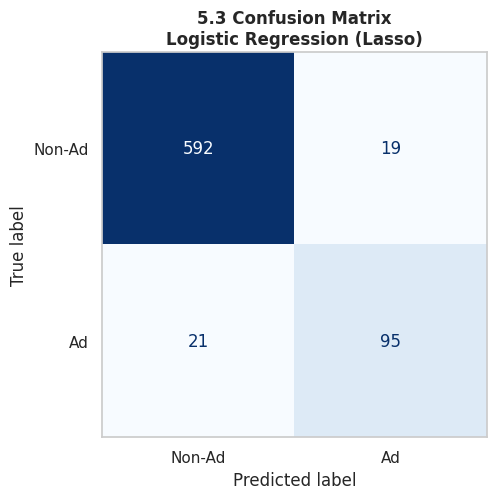

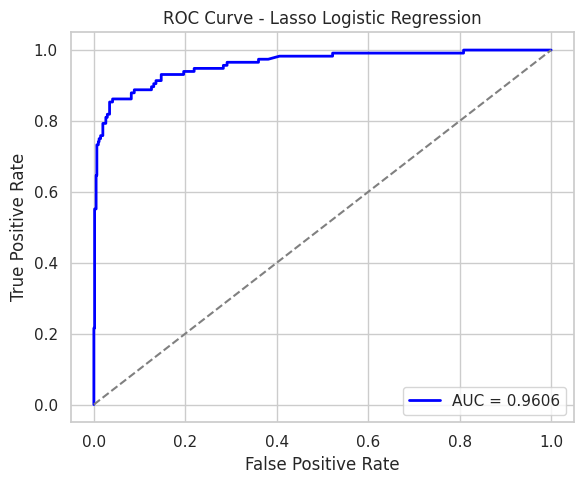

In [18]:
lasso_cv = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegressionCV(
        penalty="l1",
        solver="liblinear",
        cv=5,
        scoring="roc_auc",
        max_iter=2000,
        random_state=99
    ))
])

lasso_cv.fit(X_train, y_train, classifier__sample_weight=sample_weights)

# selected features (non-zero coefficients)
feature_names = lasso_cv.named_steps["preprocessor"].get_feature_names_out()
coef_values = lasso_cv.named_steps["classifier"].coef_.ravel()
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef_values
})
selected_features = coef_df.loc[coef_df["Coefficient"] != 0].copy()

print("\nNon-zero coefficients from Lasso:")
print(selected_features)

print("\nNumber of selected features:", len(selected_features))

# predictions
prob_pred = lasso_cv.predict_proba(X_test)[:, 1]
class_pred = (prob_pred > 0.5).astype(int)

lasso_metrics = evaluate_binary(y_test, class_pred, prob_pred, "Lasso Logistic Regression")
# Confusion Matrix Lasso
plt.figure(figsize=(6, 5))
ax = plt.gca() # Lấy axis hiện tại
disp_lasso = ConfusionMatrixDisplay(lasso_metrics['cm'], display_labels=['Non-Ad', 'Ad'])
disp_lasso.plot(ax=ax, colorbar=False, cmap='Blues') 
ax.set_title('5.3 Confusion Matrix\nLogistic Regression (Lasso)', fontweight='bold')
plt.grid(False) 
plt.show()
plot_roc(y_test, prob_pred, title="ROC Curve - Lasso Logistic Regression", color="blue")

# Cell 18 — RANDOM FOREST (ORIGINAL DATA)

**Mục đích**
- Train Random Forest trên dữ liệu gốc.
- Tính dự đoán xác suất, confusion matrix, ROC-AUC.
- Vẽ importance của top feature.


=== Random Forest ===
Confusion matrix:
[[606   5]
 [ 21  95]]
Sensitivity / Recall: 0.8190
Specificity         : 0.9918
ROC AUC             : 0.9628

Classification report:
              precision    recall  f1-score   support

  Non-Ad (0)       0.97      0.99      0.98       611
      Ad (1)       0.95      0.82      0.88       116

    accuracy                           0.96       727
   macro avg       0.96      0.91      0.93       727
weighted avg       0.96      0.96      0.96       727



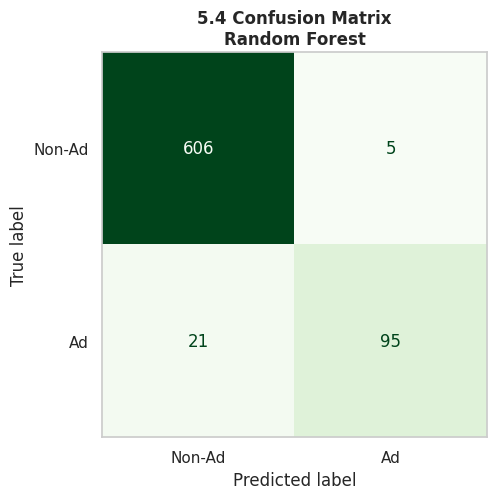

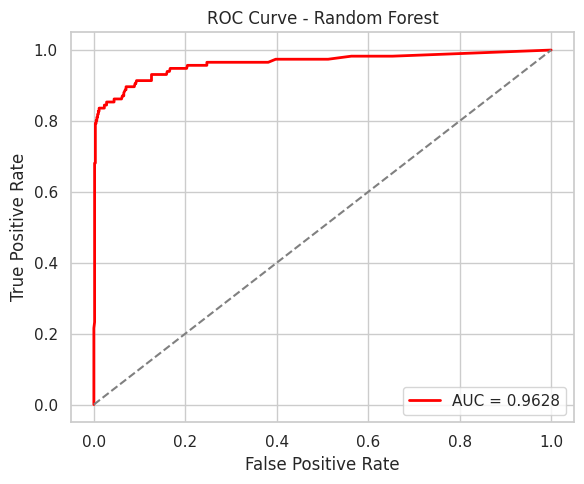

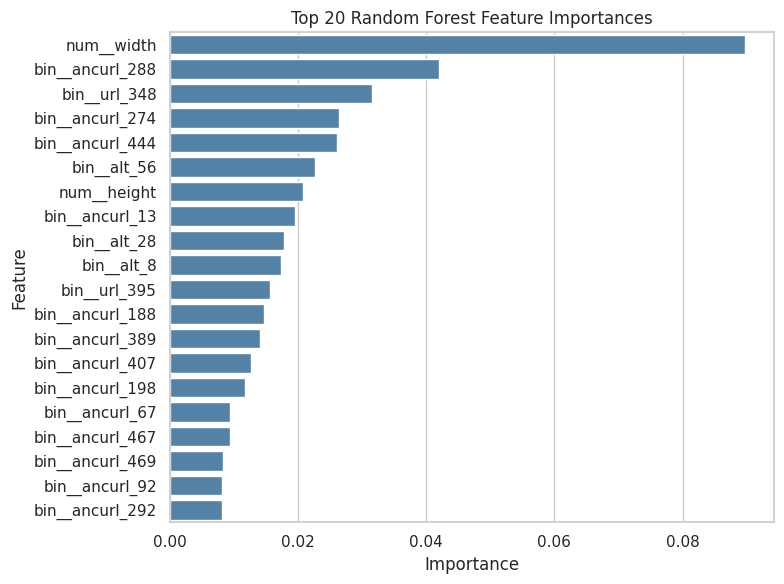

In [19]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=500,
        max_features="sqrt",
        random_state=99,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_pred = (rf_prob > 0.5).astype(int)

rf_metrics = evaluate_binary(y_test, rf_pred, rf_prob, "Random Forest")

# Confusion Matrix Random Forest
plt.figure(figsize=(6, 5))
ax = plt.gca()
disp_rf = ConfusionMatrixDisplay(rf_metrics['cm'], display_labels=['Non-Ad', 'Ad'])
disp_rf.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('5.4 Confusion Matrix\nRandom Forest', fontweight='bold')
plt.grid(False)
plt.show()
plot_roc(y_test, rf_prob, title="ROC Curve - Random Forest", color="red")

# variable importance
rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.named_steps["classifier"].feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=rf_importance.head(20), y="Feature", x="Importance", color="steelblue")
plt.title("Top 20 Random Forest Feature Importances")
plt.tight_layout()
plt.show()

# Cell 19 — REMOVE OUTLIERS (IQR METHOD)

**Mục đích**
- Loại outlier của `height` và `width` theo quy tắc IQR.
- Tạo bộ dữ liệu sạch hơn để so sánh ảnh hưởng của outlier lên mô hình.

In [20]:
def remove_outlier(df: pd.DataFrame, col: str) -> pd.DataFrame:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr_val = q3 - q1

    lower = q1 - 1.5 * iqr_val
    upper = q3 + 1.5 * iqr_val
    return df[(df[col] >= lower) & (df[col] <= upper)].copy()

ad_data_clean = ad_data.copy()
ad_data_clean = remove_outlier(ad_data_clean, "height")
ad_data_clean = remove_outlier(ad_data_clean, "width")
print("\nRows remaining after outlier removal:", len(ad_data_clean))


Rows remaining after outlier removal: 1929


# Cell 20 — TRAIN / TEST SPLIT (NO OUTLIERS)

**Mục đích**
- Chạy lại quy trình chia dữ liệu sau khi loại outlier.
- Chuẩn bị bộ train/test thứ hai để so sánh.

In [21]:
train_data2, test_data2 = train_test_split(
    ad_data_clean,
    test_size=0.3,
    random_state=99,
    stratify=ad_data_clean["Class"]
)

X_train2 = train_data2.drop(columns=["Class"])
y_train2 = train_data2["Class"].copy()

X_test2 = test_data2.drop(columns=["Class"])
y_test2 = test_data2["Class"].copy()

sample_weights2 = make_sample_weights(y_train2)
preprocessor2, _, _ = build_preprocessor(X_train2)

# Cell 21 — LASSO LOGISTIC REGRESSION (NO OUTLIERS)

**Mục đích**
- Huấn luyện lại mô hình Lasso sau khi loại outlier.
- Đánh giá xem AUC / confusion matrix có cải thiện không.


=== Lasso Logistic Regression (No Outliers) ===
Confusion matrix:
[[509  19]
 [ 14  37]]
Sensitivity / Recall: 0.7255
Specificity         : 0.9640
ROC AUC             : 0.9103

Classification report:
              precision    recall  f1-score   support

  Non-Ad (0)       0.97      0.96      0.97       528
      Ad (1)       0.66      0.73      0.69        51

    accuracy                           0.94       579
   macro avg       0.82      0.84      0.83       579
weighted avg       0.95      0.94      0.94       579



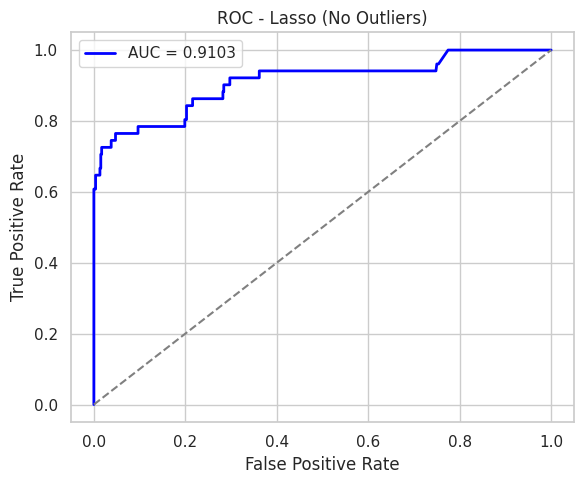

In [22]:
lasso_cv2 = Pipeline(steps=[
    ("preprocessor", preprocessor2),
    ("classifier", LogisticRegressionCV(
        penalty="l1",
        solver="liblinear",
        cv=5,
        scoring="roc_auc",
        max_iter=2000,
        random_state=99
    ))
])

lasso_cv2.fit(X_train2, y_train2, classifier__sample_weight=sample_weights2)

prob_pred2 = lasso_cv2.predict_proba(X_test2)[:, 1]
class_pred2 = (prob_pred2 > 0.5).astype(int)

lasso2_metrics = evaluate_binary(y_test2, class_pred2, prob_pred2, "Lasso Logistic Regression (No Outliers)")
plot_roc(y_test2, prob_pred2, title="ROC - Lasso (No Outliers)", color="blue")

# Cell 22 — RANDOM FOREST (NO OUTLIERS)

**Mục đích**
- Huấn luyện lại Random Forest trên bộ đã loại outlier.
- So sánh hiệu năng với bản dữ liệu gốc.


=== Random Forest (No Outliers) ===
Confusion matrix:
[[522   6]
 [ 14  37]]
Sensitivity / Recall: 0.7255
Specificity         : 0.9886
ROC AUC             : 0.9546

Classification report:
              precision    recall  f1-score   support

  Non-Ad (0)       0.97      0.99      0.98       528
      Ad (1)       0.86      0.73      0.79        51

    accuracy                           0.97       579
   macro avg       0.92      0.86      0.88       579
weighted avg       0.96      0.97      0.96       579



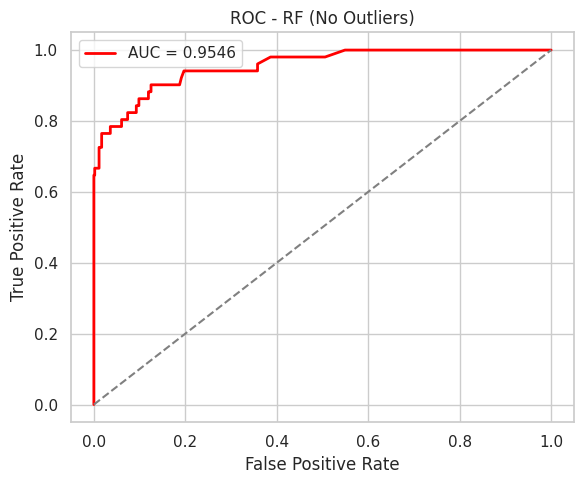

In [23]:
rf_model2 = Pipeline(steps=[
    ("preprocessor", preprocessor2),
    ("classifier", RandomForestClassifier(
        n_estimators=500,
        max_features="sqrt",
        random_state=99,
        n_jobs=-1
    ))
])

rf_model2.fit(X_train2, y_train2)

rf_prob2 = rf_model2.predict_proba(X_test2)[:, 1]
rf_pred2 = (rf_prob2 > 0.5).astype(int)

rf2_metrics = evaluate_binary(y_test2, rf_pred2, rf_prob2, "Random Forest (No Outliers)")
plot_roc(y_test2, rf_prob2, title="ROC - RF (No Outliers)", color="red")

# Cell 23 — FINAL AUC COMPARISON

**Mục đích**
- Gom kết quả AUC của 4 trường hợp:
  - Lasso dữ liệu gốc
  - RF dữ liệu gốc
  - Lasso không outlier
  - RF không outlier

In [24]:
auc_comparison = pd.DataFrame({
    "Model": [
        "Lasso (original)",
        "RF (original)",
        "Lasso (no outlier)",
        "RF (no outlier)"
    ],
    "AUC": [
        lasso_metrics["auc"],
        rf_metrics["auc"],
        lasso2_metrics["auc"],
        rf2_metrics["auc"]
    ]
})

print("\nFinal AUC comparison:")
print(auc_comparison)

# Optional save
# auc_comparison.to_csv("auc_comparison.csv", index=False)


Final AUC comparison:
                Model       AUC
0    Lasso (original)  0.960586
1       RF (original)  0.962759
2  Lasso (no outlier)  0.910335
3     RF (no outlier)  0.954564
